In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize


In [ ]:
df = pd.read_csv('/content/data.csv', encoding='latin1')
df.head()



/tmp/ipython-input-1312251884.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/data.csv', encoding='latin1')


,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01


In [ ]:
# Extract NO2 column and remove missing values
x = df['no2'].dropna().values

print("Total samples:", len(x))


Total samples: 419509


In [ ]:
r = 102303412

ar = 0.15   # computed above
br = 0.9

print("ar =", ar)
print("br =", br)


ar = 0.15
br = 0.9


In [ ]:
z = x + ar * np.sin(br * x)

print("Shape of z:", z.shape)


Shape of z: (419509,)


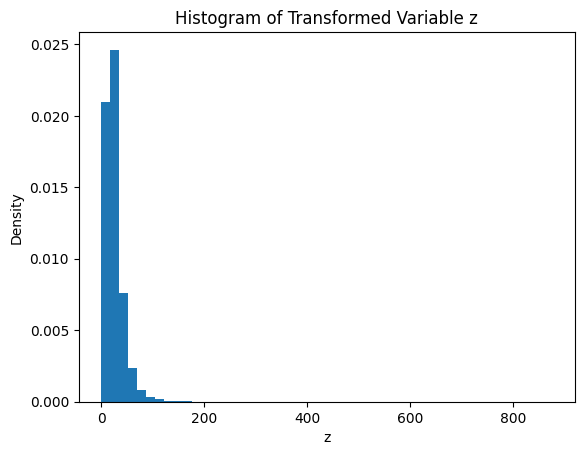

In [ ]:
plt.hist(z, bins=50, density=True)
plt.title("Histogram of Transformed Variable z")
plt.xlabel("z")
plt.ylabel("Density")
plt.show()


In [ ]:
def pdf_model(params, z):
    lam, mu, c = params
    return c * np.exp(-lam * (z - mu)**2)


In [ ]:
def negative_log_likelihood(params, z):
    lam, mu, c = params

    if lam <= 0 or c <= 0:
        return np.inf

    p = pdf_model(params, z)
    p = np.clip(p, 1e-10, None)

    return -np.sum(np.log(p))


In [ ]:
initial_params = [0.01, np.mean(z), 1]

result = minimize(
    negative_log_likelihood,
    initial_params,
    args=(z,),
    method='L-BFGS-B',
    bounds=[(1e-6, None), (None, None), (1e-6, None)]
)

lam_est, mu_est, c_est = result.x

print("Estimated Parameters:")
print("lambda =", lam_est)
print("mu =", mu_est)
print("c =", c_est)


Estimated Parameters:
lambda = 1e-06
mu = 68.42581579152497
c = 5590.77810492493


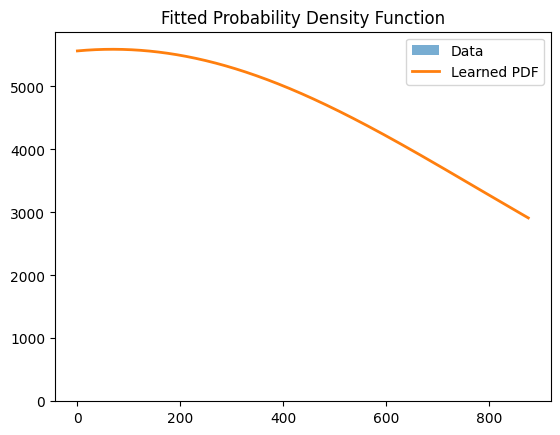

In [ ]:
z_range = np.linspace(min(z), max(z), 500)
pdf_values = pdf_model([lam_est, mu_est, c_est], z_range)

plt.hist(z, bins=50, density=True, alpha=0.6, label="Data")
plt.plot(z_range, pdf_values, linewidth=2, label="Learned PDF")
plt.legend()
plt.title("Fitted Probability Density Function")
plt.show()


In [ ]:
print("Mean of z:", np.mean(z))
print("Variance of z:", np.var(z))


Mean of z: 25.805474175407145
Variance of z: 342.5452264799269


In [ ]:
lambda_theoretical = 1 / (2 * np.var(z))
print("Theoretical lambda:", lambda_theoretical)


Theoretical lambda: 0.0014596612690771212
